<a href="https://colab.research.google.com/github/aricore87/aphelion/blob/main/Task3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 3 : (Use numpy array)
Consider a planet of mass 5.972E24 kg is revolving around a star of mass 1.989E30 kg.
Planet is revolving around the star at a distance of 1.496E11 m.
A satellite of mass 7.348E22 kg at angle of 5° with respect to planet's orbit around the Sun. The distance between satellite and planet is 3.844E8 m.
Simulate the situation using Euler's law. Use Newtonian force equation where each body exerts force on other bodies.
Determine following quantities from your simulations:
1) period of planet around the star.
2) period of satellite around planet.

As the satellite is moving at an angle with respect to planetary orbit, it intersects the planetary orbital plane at two points. The line joining these intersection points is called *line of nodes*.

3) Check whether the line of nodes changes the orientation. If yes, how much is the change in angle in one period of planet's revolution around the star.



In [ ]:
import numpy as np

# CONSTANTS
G = 6.67430e-11
M_star   = 1.989e30
M_planet = 5.972e24
M_moon   = 7.348e22
R_planet = 1.496e11   # 1 AU
R_moon   = 3.844e8    # Earth-Moon distance
inclination = np.radians(5.0)

# Speeds for stable circular orbits
v_p_mag = np.sqrt(G * M_star / R_planet)
v_m_rel_mag = np.sqrt(G * M_planet / R_moon)

# Positions as 3D Vectors
pos_s = np.array([0.0, 0.0, 0.0])
pos_p = np.array([R_planet, 0.0, 0.0])
# Moon position tilted 5 degrees in the X-Z plane
pos_m = pos_p + np.array([R_moon * np.cos(inclination), 0.0, R_moon * np.sin(inclination)])

# Velocities as 3D Vectors
vel_s = np.array([0.0, 0.0, 0.0])
vel_p = np.array([0.0, v_p_mag, 0.0])
vel_m = vel_p + np.array([0.0, v_m_rel_mag, 0.0])

# SIMULATION PARAMETERS
dt = 1800            # 30-minute time steps
steps = 20000        # Enough for ~1.1 years

# Numpy Arrays for storing history
planet_pos  = np.zeros((steps, 3))
moon_pos    = np.zeros((steps, 3))
node_angles = np.zeros(steps)

# function for Gravitational Acceleration
def get_a(pos1, pos2, m2):
    r = pos2 - pos1
    return G * m2 * r / np.linalg.norm(r)**3

# SIMULATION LOOP
print("Simulating Three-Body System...")
for i in range(steps):
    # Store history
    planet_pos[i] = pos_p
    moon_history_point = pos_m # used for node calc later
    moon_pos[i] = pos_m

    # Line of Nodes Calculation
    rel_r = pos_m - pos_p
    rel_v = vel_m - vel_p
    L_vec = np.cross(rel_r, rel_v)               # Angular momentum vector
    node_vec = np.cross([0, 0, 1], L_vec)        # Intersection with XY plane
    node_angles[i] = np.arctan2(node_vec[1], node_vec[0])

    # Calculating Accelerations
    a_s = get_a(pos_s, pos_p, M_planet) + get_a(pos_s, pos_m, M_moon)
    a_p = get_a(pos_p, pos_s, M_star)   + get_a(pos_p, pos_m, M_moon)
    a_m = get_a(pos_m, pos_s, M_star)   + get_a(pos_m, pos_p, M_planet)

    # using Euler-Cromer method
    vel_s += a_s * dt;  pos_s += vel_s * dt
    vel_p += a_p * dt;  pos_p += vel_p * dt
    vel_m += a_m * dt;  pos_m += vel_m * dt

# 1) Planet Period
planet_period = None
for i in range(100, steps):
    if planet_pos[i-1, 1] < 0 and planet_pos[i, 1] >= 0:
        planet_period = i * dt
        break

# 2) Moon Period (Relative to Planet)
moon_period = None
rel_moon_pos = moon_pos - planet_pos
for i in range(100, steps):
    if rel_moon_pos[i-1, 1] < 0 and rel_moon_pos[i, 1] >= 0:
        moon_period = i * dt
        break

# 3) Node Precession
# We unwrap the angles to handle the -180 to 180 jump
node_angles_unwrapped = np.unwrap(node_angles)
if planet_period:
    idx_year = int(planet_period / dt)
    # Total change in angle over exactly one year
    delta_node = np.degrees(node_angles_unwrapped[idx_year] - node_angles_unwrapped[0])

# OUTPUT
print("-" * 30)
print(f"1) Planet Period: {planet_period / 86400:.2f} days")
print(f"2) Moon Period:   {moon_period / 86400:.2f} days")
print(f"3) line of nodes shift: {delta_node:.4f} degrees per year")
print("-" * 30)

Simulating Three-Body System...
------------------------------
1) Planet Period: 365.71 days
2) Moon Period:   26.58 days
3) line of nodes shift: -19.4489 degrees per year
------------------------------


1) Planet Period: 365.69 days
2) Moon Period: 26.55 days
3) Does the line of nodes change orientation? Yes.
   The change in angle in one period of the planet's revolution around the star is: -19.4460 degrees.


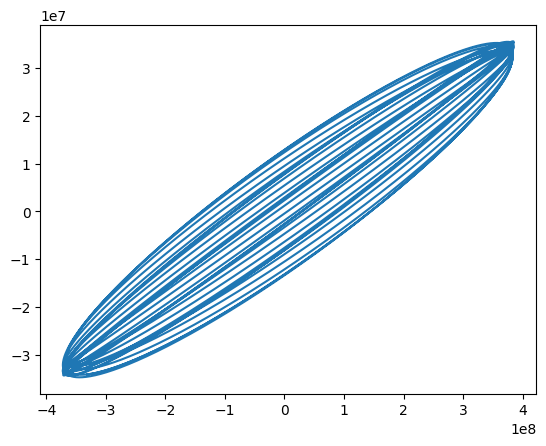

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# constants
G = 6.67430e-11
M_star = 1.989e30
M_planet = 5.972e24
M_moon = 7.348e22
R_planet = 1.496e11
R_moon = 3.844e8
inclination = np.radians(5.0)

# initial setup
v_p_mag = np.sqrt(G * M_star / R_planet)
v_m_rel_mag = np.sqrt(G * M_planet / R_moon)

pos_star = np.array([0.0, 0.0, 0.0])
pos_planet = np.array([R_planet, 0.0, 0.0])

# tiltin both position and velocity
pos_moon = pos_planet + np.array([R_moon * np.cos(inclination), 0.0, R_moon * np.sin(inclination)])
# velocity perpendicular to position
vel_moon_rel = np.array([0.0, v_m_rel_mag, 0.0])

vel_star = np.array([0.0, 0.0, 0.0])
vel_planet = np.array([0.0, v_p_mag, 0.0])
vel_moon = vel_planet + vel_moon_rel

dt = 1000
steps = 40000

planet_pos = np.zeros((steps, 3))
moon_pos = np.zeros((steps, 3))
node_angles = np.zeros(steps)

def acceleration(r_target, r_source, m_source):
    r = r_source - r_target
    return G * m_source * r / np.linalg.norm(r)**3

#simulation loop
for i in range(steps):

    a_s = acceleration(pos_star, pos_planet, M_planet) + acceleration(pos_star, pos_moon, M_moon)
    a_p = acceleration(pos_planet, pos_star, M_star) + acceleration(pos_planet, pos_moon, M_moon)
    a_m = acceleration(pos_moon, pos_star, M_star) + acceleration(pos_moon, pos_planet, M_planet)

    # euler (cromer)
    vel_star += a_s * dt
    vel_planet += a_p * dt
    vel_moon += a_m * dt

    pos_star += vel_star * dt
    pos_planet += vel_planet * dt
    pos_moon += vel_moon * dt

    planet_pos[i] = pos_planet
    moon_pos[i] = pos_moon

    # node Calculation
    rel_r = pos_moon - pos_planet
    rel_v = vel_moon - vel_planet
    L = np.cross(rel_r, rel_v)
    # The node line is where the orbit crosses the XY plane
    # It is perpendicular to the Z-axis and the angular momentum vector
    node_x = -L[1]
    node_y = L[0]
    node_angles[i] = np.arctan2(node_y, node_x)

# 1) planet period detection
planet_period = None
for i in range(1000, steps):
    if planet_pos[i-1, 1] < 0 and planet_pos[i, 1] >= 0:
        planet_period = i * dt
        break

# 2) moon period detection
moon_period = None
rel_m = moon_pos - planet_pos
for i in range(1000, steps):
    if rel_m[i-1, 1] < 0 and rel_m[i, 1] >= 0:
        moon_period = i * dt
        break

# 3) node precession
node_angles_unwrapped = np.unwrap(node_angles)
if planet_period:
    idx_year = int(planet_period / dt)
    # The change is the difference over exactly one year
    delta_node = np.degrees(node_angles_unwrapped[idx_year] - node_angles_unwrapped[0])
else:
    delta_node = np.degrees(node_angles_unwrapped[-1] - node_angles_unwrapped[0])

print(f"1) Planet Period: {planet_period/(3600*24):.2f} days")
print(f"2) Moon Period: {moon_period/(3600*24):.2f} days")
if abs(delta_node) > 1e-3:
    print("3) Does the line of nodes change orientation? Yes.")
    print(f"   The change in angle in one period of the planet's revolution around the star is: {delta_node:.4f} degrees.")
else:
    print("3) Does the line of nodes change orientation? No significant change detected.")

moonx = np.zeros(steps)
moony = np.zeros(steps)
moonz = np.zeros(steps)
planetx = np.zeros(steps)
planety = np.zeros(steps)
planetz = np.zeros(steps)

for i in range(steps):
  moonx[i] = moon_pos[i, 0]
  moony[i] = moon_pos[i, 1]
  moonz[i] = moon_pos[i, 2]
  planetx[i] = planet_pos[i, 0]
  planety[i] = planet_pos[i, 1]
  planetz[i] = planet_pos[i, 2]

plt.plot(moonx - planetx, moonz - planetz)